# Orange County Analysis

In [254]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import src.analysis_utils as analysis_utils
import src.table_utils as table_utils
import src.visualization_utils as visualization_utils
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# Display all columns
pd.set_option('display.max_columns', None)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Import Data

In [255]:
# Load in policing data
original_policing = pd.read_csv("../data/processed/cleaned_orange_ripa_2022_2024.csv", low_memory=False)

# Select only relevant columns to use
keep_cols = [
    "doj_record_id",
    "person_number",
    "agency_ori",
    "agency_name",
    "time_of_stop",
    "date_of_stop",
    "year",
    "stop_duration",
    "closest_city",
    "race_ethnicity",
    "gender",
    "age",
    "reason_for_contact",
    "traffic_violation_cjis_offense_code",
    "suspicion_cjis_offense_code",
    "suspicion",
    "action_any_search",
    "search_basis_plain_view",
    "search_basis_plain_smell",
    "search_basis_consent",
    "search_basis_safety",
    "search_basis_suspect_weapon",
    "search_basis_evidence_of_crime",
    "search_basis_school_policy",
    "search_basis_emergency",
    "search_basis_canine",
    "search_basis_warrant",
    "search_basis_probation",
    "search_basis_incident_to_arrest",
    "search_basis_vehicle_inventory",
    "contraband_any",
    "result_of_stop_arrest",
    "search_type",
    "multi_person_stop"
]
policing = original_policing[[c for c in keep_cols if c in original_policing.columns]].copy()

In [256]:
# Load in prosecution data
prosecution = pd.read_csv("https://raw.githubusercontent.com/laurenbchu/honors-thesis/main/data/processed/cleaned_orange_aclu_2021_2023.csv", low_memory=False)
prosecution['filed_date'] = pd.to_datetime(prosecution["filed_date"])
prosecution['Year'] = prosecution['filed_date'].dt.year

In [257]:
# Load in census data
census = analysis_utils.load_census("06059")

# Roll-up census data to be more coarse to match policing/prosecution race categories
census_coarse = analysis_utils.census_rollup(census)

# Policing Analysis: Stop Rates, Search Rates, and Hit Rates

In [258]:
# Filter for only discretionary stops
policing = policing[policing["reason_for_contact"].isin([
    "Moving violation",
    "Equipment violation",
    "Non-moving violation",
    "Suspect criminal activity"
])].copy()

# Add standardized race column to match policing and prosecution labels
policing = analysis_utils.add_standardized_race(policing, "race_ethnicity")

# Consider only purely discretionary searches in search and hit rates

# Clean contraband_any (handles NaN, 0/1, True/False)
policing["contraband_any"] = policing["contraband_any"].fillna(0).astype(int)

# Create discretionary search indicator
policing["disc_search"] = policing["action_any_search"] & policing["search_type"].eq("Discretionary only")

# Create hits among discretionary searches indicator
# Hits only count as hits if they were found in a search, and the search was discretionary
policing["disc_hit"] = (
    policing["disc_search"] & # Has to be from a discretionary search
    policing["action_any_search"].fillna(False) & # Has to have been searched
    (policing["contraband_any"] == 1)
)

# Create a copy with all people involved in stops for sensitivity analysis
policing_multi = policing.copy()

# Filter for person 1 for each stop (usually, the main person stopped, but not always)
policing = policing[policing["person_number"] == 1].copy()

policing_analysis = analysis_utils.policing_rates(policing, census_coarse)

In [259]:
import numpy as np

# ── Pooled policing summary table (2022-2024) ──────────────────────────────

race_order = ["Black/African American", "Hispanic/Latino", "White", "Asian", "Other"]

df = policing_analysis.copy()

# Population (fixed — same across years, just take first)
pop_pooled = (
    df[["Perceived Race", "Population"]]
    .drop_duplicates("Perceived Race")
    .set_index("Perceived Race")
    .reindex(race_order)
)

# Stops per 1,000: mean across years (no CI)
stops_pooled = (
    df.groupby("Perceived Race")["Stops per 1,000"]
    .mean()
    .reindex(race_order)
    .apply(lambda x: f"{x:.2f}")
    .rename("Stops per 1,000")
)

# Searches per 1,000: mean across years (no CI)
searches_pooled = (
    df.groupby("Perceived Race")["Searches per 1,000"]
    .mean()
    .reindex(race_order)
    .apply(lambda x: f"{x:.2f}")
    .rename("Searches per 1,000")
)

# Search rate: pool counts across years, then compute rate + SE
search_counts = (
    df.groupby("Perceived Race")[["Search Count", "Stop Count"]]
    .sum()
    .reindex(race_order)
)
search_counts["Search Rate"] = (
    search_counts["Search Count"] / search_counts["Stop Count"]
)
search_counts["Search Rate SE"] = np.sqrt(
    search_counts["Search Rate"] *
    (1 - search_counts["Search Rate"]) /
    search_counts["Stop Count"]
)
search_counts["Search Rate (%)"] = search_counts.apply(
    lambda row: (
        f"{row['Search Rate']*100:.2f} "
        f"(±{row['Search Rate SE']*100*1.96:.2f})"
    ),
    axis=1,
)

# Hit rate: pool counts across years, then compute rate + SE
hit_counts = (
    df.groupby("Perceived Race")[["Hit Count", "Search Count"]]
    .sum()
    .reindex(race_order)
)
hit_counts["Hit Rate"] = (
    hit_counts["Hit Count"] / hit_counts["Search Count"]
)
hit_counts["Hit Rate SE"] = np.sqrt(
    hit_counts["Hit Rate"] *
    (1 - hit_counts["Hit Rate"]) /
    hit_counts["Search Count"]
)
hit_counts["Hit Rate (%)"] = hit_counts.apply(
    lambda row: (
        f"{row['Hit Rate']*100:.2f} "
        f"(±{row['Hit Rate SE']*100*1.96:.2f})"
    ),
    axis=1,
)

# Combine into single display table
table_policing_pooled = pd.concat(
    [
        pop_pooled["Population"],
        stops_pooled,
        searches_pooled,
        search_counts["Search Rate (%)"],
        hit_counts["Hit Rate (%)"],
    ],
    axis=1,
)

table_policing_pooled.columns = [
    "Population",
    "Stops per 1,000",
    "Searches per 1,000",
    "Search Rate (%) [95% CI]",
    "Hit Rate (%) [95% CI]",
]

table_policing_pooled
# table_utils.export_policing_pooled_to_latex(policing_analysis)

,Population,"Stops per 1,000","Searches per 1,000",Search Rate (%) [95% CI],Hit Rate (%) [95% CI]
Perceived Race,,,,,
Black/African American,49304,171.91,15.19,8.84 (±0.35),26.39 (±1.82)
Hispanic/Latino,1086834,65.19,6.12,9.39 (±0.12),27.81 (±0.62)
White,1198655,49.36,2.87,5.81 (±0.11),36.12 (±0.93)
Asian,699124,28.17,0.71,2.51 (±0.13),31.06 (±2.36)
Other,153072,70.79,1.98,2.79 (±0.18),26.32 (±2.86)


In [260]:
# Creating tables
race_order = ["Black/African American", "Hispanic/Latino", "White", "Asian", "Other"]

df = policing_analysis.copy()

pop = (df[["Perceived Race", "Population"]]
       .drop_duplicates("Perceived Race")
       .set_index("Perceived Race")
       .reindex(race_order))

def make_pivot_no_ci(df, value_col, digits=2):
    """Plain pivot with no CI — just the formatted number."""
    tmp = df[["Perceived Race", "Year", value_col]].copy()
    tmp["cell"] = tmp[value_col].apply(lambda x: f"{x:.{digits}f}")
    wide = tmp.pivot(index="Perceived Race", columns="Year", values="cell")
    wide = wide.reindex(columns=[y for y in (2022, 2023, 2024) if y in wide.columns])
    return wide

stops_1k    = make_pivot_no_ci(df, "Stops per 1,000")
searches_1k = make_pivot_no_ci(df, "Searches per 1,000")

tab2 = df.copy()
tab2["Search Rate"] *= 100
tab2["Hit Rate"]    *= 100
tab2["Search Rate SE"] *= 100
tab2["Hit Rate SE"]    *= 100

search_rate = table_utils.make_pivot_with_ci(tab2, "Search Rate", "Search Rate SE")
hit_rate    = table_utils.make_pivot_with_ci(tab2, "Hit Rate", "Hit Rate SE")

table_policing = pd.concat(
    [pop, stops_1k, searches_1k, search_rate, hit_rate],
    axis=1,
    keys=["Population", "Stops per 1,000", "Searches per 1,000",
          "Search Rate (%)", "Hit Rate (%)"]
)

table_policing.columns = pd.MultiIndex.from_tuples(
    [(g, c) for g, c in table_policing.columns],
    names=["", "Year"]
)

table_policing = table_policing.reindex(race_order)

# Export — pass policing_analysis, NOT table_policing
table_utils.export_policing_by_year(policing_analysis)

table_policing

Table exported: policing_by_year.tex


Population Stops per 1,000                  \
Year                   Population            2022    2023    2024   
Perceived Race                                                      
Black/African American      49304          176.88  158.14  180.70   
Hispanic/Latino           1086834           65.75   58.48   71.35   
White                     1198655           52.00   44.19   51.89   
Asian                      699124           28.52   26.03   29.96   
Other                      153072           69.77   61.83   80.77   

                       Searches per 1,000               Search Rate (%)  \
Year                                 2022   2023   2024            2022   
Perceived Race                                                            
Black/African American              16.33  13.49  15.76    9.23 (±0.61)   
Hispanic/Latino                      5.89   5.41   7.06    8.96 (±0.21)   
White                                3.12   2.47   3.02    6.01 (±0.19)   
Asian                                0.73   0.67   0.71    2.57 (±0.22)   
Other                                1.91   1.57   2.44    2.74 (±0.31)   

                                                     Hit Rate (%)  \
Year                            2023          2024           2022   
Perceived Race                                                      
Black/African American  8.53 (±0.62)  8.72 (±0.59)  29.19 (±3.14)   
Hispanic/Latino         9.25 (±0.23)  9.89 (±0.21)  30.72 (±1.13)   
White                   5.58 (±0.20)  5.81 (±0.18)  37.06 (±1.55)   
Asian                   2.59 (±0.23)  2.37 (±0.21)  31.97 (±4.04)   
Other                   2.55 (±0.32)  3.02 (±0.30)  29.01 (±5.20)   

                                                      
Year                             2023           2024  
Perceived Race                                        
Black/African American  25.11 (±3.30)  24.58 (±3.03)  
Hispanic/Latino         27.52 (±1.14)  25.60 (±0.98)  
White                   37.62 (±1.75)  33.91 (±1.54)  
Asian                   30.36 (±4.15)  30.78 (±4.06)  
Other                   23.65 (±5.37)  25.94 (±4.44)

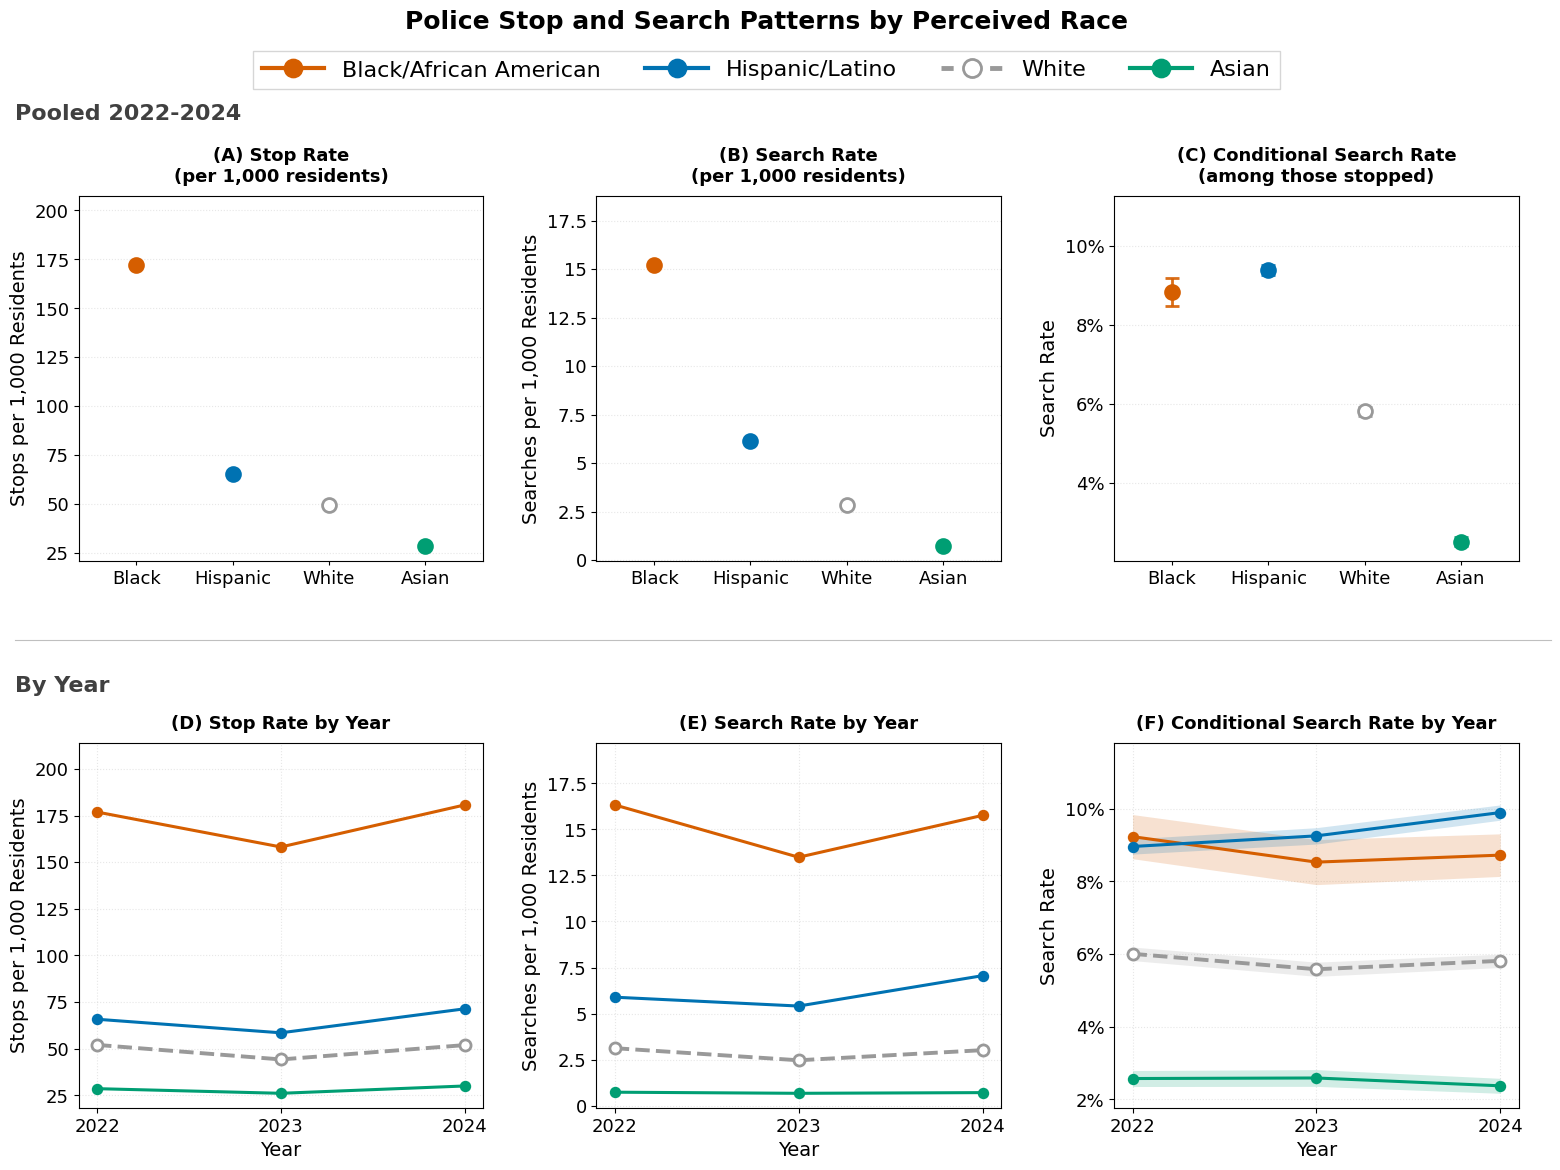

In [261]:
policing_figs = visualization_utils.plot_policing_by_year(policing_analysis)
# visualization_utils.export_figure_to_pdf(policing_figs, "policing")

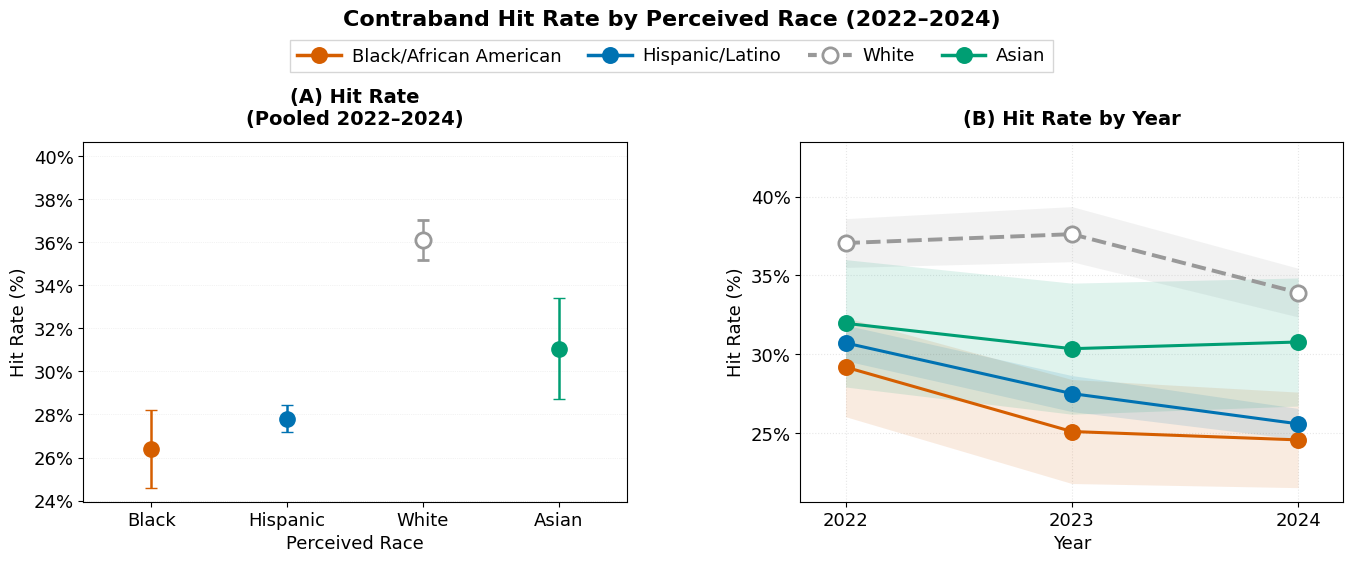

In [262]:
hit_rate_appendix_fig = visualization_utils.plot_hit_rate_by_year(policing_analysis)
# visualization_utils.export_figure_to_pdf(hit_rate_appendix_fig, "03_policing_hit")

# Policing Analysis: Stratified by Reason for Contact

In [263]:
# Calculate rates by reason for contact
policing_by_reason = analysis_utils.policing_rates_by_reason_for_contact(policing, census_coarse)

# Create comprehensive table with pooled 2022-2024 data
reason_table = table_utils.create_reason_for_contact_table(policing_by_reason)
display(reason_table)
# table_utils.export_reason_for_contact_table_to_latex(reason_table)

,Reason for Contact,Perceived Race,Stops,Searches,Search Rate (%),Hit Rate (%)
0,Moving violation,Black/African American,9754,323,3.31 (±0.36),18.27 (±4.21)
1,,Hispanic/Latino,93087,4782,5.14 (±0.14),17.04 (±1.07)
2,,White,97652,1586,1.62 (±0.08),28.06 (±2.21)
3,,Asian,38581,300,0.78 (±0.09),22.67 (±4.74)
4,,Other,21428,202,0.94 (±0.13),19.31 (±5.44)
5,Equipment violation,Black/African American,7054,615,8.72 (±0.66),20.98 (±3.22)
6,,Hispanic/Latino,62378,5943,9.53 (±0.23),25.81 (±1.11)
7,,White,33380,2560,7.67 (±0.29),35.23 (±1.85)
8,,Asian,9761,394,4.04 (±0.39),31.22 (±4.58)
9,,Other,5826,247,4.24 (±0.52),25.10 (±5.41)


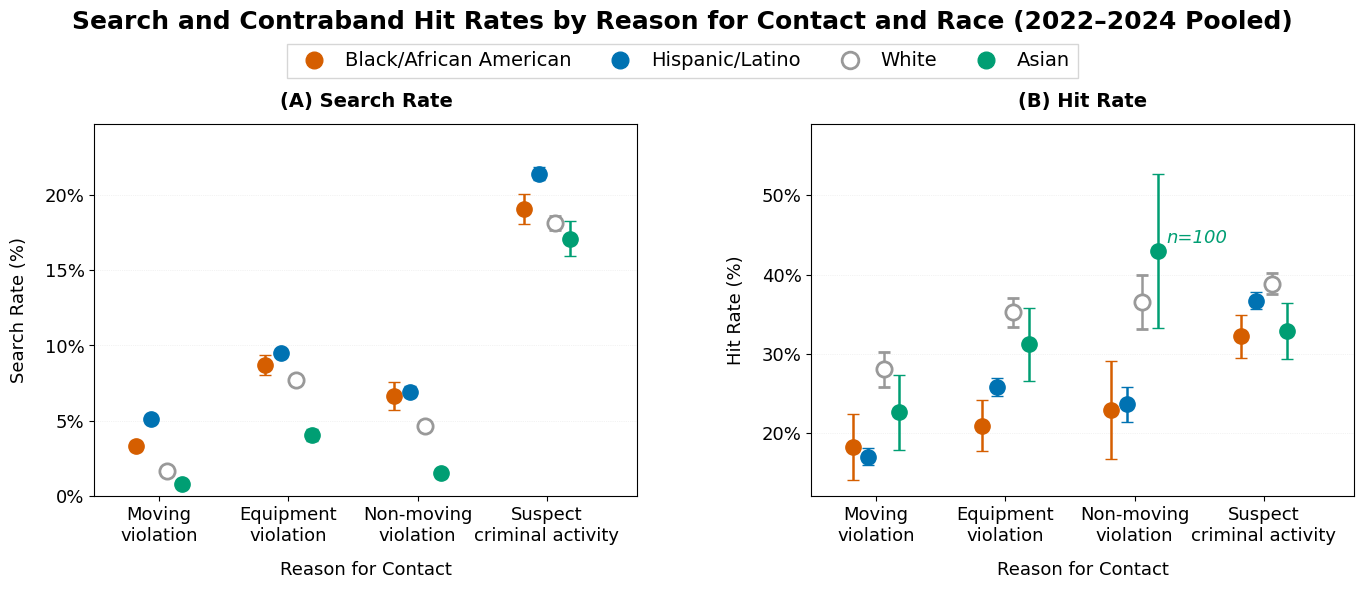

In [264]:
# Create search rate visualization
fig_search = visualization_utils.visualize_search_and_hit_rates_by_reason(policing_by_reason)
# visualization_utils.export_figure_to_pdf(fig_search, "03_policing_by_reason")

# Policing Analysis: Black and White Hit Rates by Agency

In [ ]:
# Calculate the White and Black hit rates for each agency and summarize in a table
agency_hit_summary = analysis_utils.summarize_agency_black_white_hit_rates(policing)
publication_table = table_utils.agency_black_white_hit_rate_table(agency_hit_summary)
publication_table
# table_utils.export_agency_hit_rates_to_latex(agency_hit_summary)

Table exported: agency_hits.tex (7 agencies flagged with dagger)


"\\begin{table}[htbp]\n\\centering\n\\caption{Agency-Level Comparison: White vs.\\ Black/African American Hit Rates}\n\\label{tab:agency_hit_rates}\n\\begin{tabular}{l rr rr}\n\\toprule\n & \\multicolumn{2}{c}{White} & \\multicolumn{2}{c}{Black/African American} \\\\\n\\cmidrule(lr){2-3} \\cmidrule(lr){4-5}\nAgency & Searches & Hit Rate (\\%) & Searches & Hit Rate (\\%) \\\\\n\\midrule\nAnaheim PD & 1,248 & 35.9 ({\\scriptsize $\\pm$2.7}) & 328 & 24.4 ({\\scriptsize $\\pm$4.6}) \\\\\nBrea PD & 219 & 42.9 ({\\scriptsize $\\pm$6.6}) & 67 & 41.8 ({\\scriptsize $\\pm$11.8}) \\\\\nBuena Park PD & 261 & 30.3 ({\\scriptsize $\\pm$5.6}) & 142 & 23.2 ({\\scriptsize $\\pm$6.9}) \\\\\nCal State Fullerton PD\\textsuperscript{\\dag} & 38 & 60.5 ({\\scriptsize $\\pm$15.5}) & 9 & 22.2 ({\\scriptsize $\\pm$27.2}) \\\\\nCosta Mesa PD & 463 & 50.3 ({\\scriptsize $\\pm$4.6}) & 77 & 31.2 ({\\scriptsize $\\pm$10.3}) \\\\\nCypress PD & 111 & 48.6 ({\\scriptsize $\\pm$9.3}) & 43 & 39.5 ({\\scriptsize $\\pm$1

In [ ]:
fig_agency_hit = visualization_utils.plot_agency_black_white_hit_rates(agency_hit_summary)
# visualization_utils.export_figure_to_pdf(fig_agency_hit, "agency_hits")

Saved: agency_hits.pdf


# Policing Sensitivity Analysis: Mixed Search Bases and Multiperson Stops

In [ ]:
# Checks sensitivity of search and hit rates to including searches with mixed legal bases (e.g. "Mixed" or "No search basis") as discretionary searches

policing["disc_search_mixed"] = (
    policing["action_any_search"]
    & policing["search_type"].isin(["Discretionary only", "Mixed", "No search basis"])
)

policing["disc_hit_mixed"] = (
    policing["disc_search_mixed"]
    & policing["action_any_search"].fillna(False)
    & (policing["contraband_any"] == 1)
)

policing_analysis_mixed = analysis_utils.policing_rates_sensitivity(
    policing,
    census_coarse,
    "mixed"
)

# Checks sensitivity of search and hit rates to including all people involved in stops (not just person 1) for multiperson stops

policing_multi.rename(
    columns={"disc_search": "disc_search_multiperson"},
    inplace=True
)

policing_multi["disc_hit_multiperson"] = (
    policing_multi["disc_search_multiperson"]
    & policing_multi["action_any_search"].fillna(False)
    & (policing_multi["contraband_any"] == 1)
)

policing_analysis_multiperson = analysis_utils.policing_rates_sensitivity(
    policing_multi,
    census_coarse,
    "multiperson"
)

In [ ]:
# Creates one table for 2024

def make_2024_block(df, label):
    """Return a 2024 table with formatted Search/Hit rates for one method."""
    d = df[df["Year"] == 2024].copy()
    d = d.set_index("Perceived Race")

    def special_fmt_est_ci(rate, se, digits=2):
        pct = rate * 100
        ci = 1.96 * se * 100
        return f"{pct:.{digits}f} (±{ci:.{digits}f})"

    out = pd.DataFrame(index=d.index)
    out[("Search Rate (%)", label)] = [
        special_fmt_est_ci(e, s, 2)
        for e, s in zip(d["Search Rate"], d["Search Rate SE"])
    ]
    out[("Hit Rate (%)", label)] = [
        special_fmt_est_ci(e, s, 2)
        for e, s in zip(d["Hit Rate"], d["Hit Rate SE"])
    ]
    return out

# Build 2024 display blocks
baseline_2024 = make_2024_block(policing_analysis.copy(), "Baseline")
mixed_2024 = make_2024_block(policing_analysis_mixed.copy(), "Mixed")
multiperson_2024 = make_2024_block(policing_analysis_multiperson.copy(), "Multiperson")

# Join into one combined display table
table3 = baseline_2024.join(mixed_2024, how="outer").join(multiperson_2024, how="outer")

# Enforce row order
race_order = ["Black/African American", "Hispanic/Latino", "White", "Asian", "Other"]
table3 = table3.reindex(race_order)

# Enforce column order
table3 = table3[
    [
        ("Search Rate (%)", "Baseline"),
        ("Search Rate (%)", "Mixed"),
        ("Search Rate (%)", "Multiperson"),
        ("Hit Rate (%)", "Baseline"),
        ("Hit Rate (%)", "Mixed"),
        ("Hit Rate (%)", "Multiperson"),
    ]
]

table3.columns = pd.MultiIndex.from_tuples(table3.columns, names=["", ""])
table3.index.name = "Perceived Race"

table3
# export_combined_sensitivity_to_latex(policing_analysis, policing_analysis_mixed, policing_analysis_multiperson)

In [ ]:
sensitivity_fig = visualization_utils.create_combined_sensitivity_visualization(
    policing_analysis,
    policing_analysis_mixed,
    policing_analysis_multiperson
)

# visualization_utils.export_figure_to_pdf(sensitivity_fig, "sensitivity")

# Prosecution Analysis: Enhancement Rates by Charge and Statute Level

In [ ]:
# Harmonizes race labels
prosecution = analysis_utils.add_standardized_race(prosecution, 'canonical_race')

# Identify charges that are enhancements/priors/sentencing considerations rather than actual substantive criminal charges
prosecution['is_non_substantive'] = (
    prosecution['is_enhancement_charge'].astype(bool) |
    prosecution['is_special_circumstance'].astype(bool) |
    prosecution['is_sentencing_charge'].astype(bool)
)

# Apply categorization ONLY to substantive charges
prosecution.loc[~prosecution['is_non_substantive'], 'charge_category'] = \
    prosecution.loc[~prosecution['is_non_substantive'], 'charge_description'].apply(analysis_utils.categorize_charge)

# For non-substantive charges, label them explicitly as ehancement/prior/sentencing
prosecution.loc[prosecution['is_non_substantive'], 'charge_category'] = 'Enhancement/Prior/Sentencing'

# Each case is a single defendant, so case-level = defendant-case-level
# For each case, if any charge is an enhancement charge, then the case is flagged as having an enhancement charge
enh_flag = (
    prosecution.groupby('source_case_id')['is_enhancement_charge']
    .max()
    .rename('any_enhancement_in_case')
    .reset_index()
)

# Drop the enhancement rows, keeping only the base charges
substantive = prosecution[~prosecution['is_non_substantive']].copy()

# Add the enhancement flag to the dataframe
substantive = substantive.merge(enh_flag, on='source_case_id', how='left')
substantive['any_enhancement_in_case'] = substantive['any_enhancement_in_case'].fillna(0).astype(int)

# Calculate enhancement rates by charge category
# For each case, a primary charge category and statute level is assigned
# Then computes cases with any enhancement charge over total cases for each charge category
enhancement_by_primary = analysis_utils.enhancement_rates_by_primary_severity(substantive)

# Calculate and display average enhancement rates by primary charge category
enhancement_by_primary.groupby("primary_charge_category").apply(lambda g: g["Enhanced"].sum() / g["N"].sum()).sort_values(ascending=False)

# Excludes the "Other" category and categories with less than a 5% average enhancement rate across all races and statute levels
filtered_enhancement = enhancement_by_primary[
    enhancement_by_primary["primary_charge_category"].isin(
        enhancement_by_primary.groupby("primary_charge_category")
        .apply(lambda g: g["Enhanced"].sum() / g["N"].sum())
        .loc[lambda s: (s >= 0.05) & (s.index != "Other")]
        .index
    )
].copy()

In [ ]:
# Table 1: By race and statute level
enhancement_combined = table_utils.enhancement_rate_combined_table(enhancement_by_primary)
display(enhancement_combined)

# Table 2: By race, statute level, and primary category (for all categories)
# Excludes the "Other" category and categories with less than a 5% overall enhancement rate
enhancement_category = table_utils.enhancement_rate_race_statute_category_table(filtered_enhancement)
display(enhancement_category)

# export_enhancement_tables_to_latex(enhancement_combined, enhancement_category)

In [ ]:
# Plot: By race and statute level

without_other = enhancement_by_primary[enhancement_by_primary["race_std"] != "Other"].copy()
enhancement_rate_race_statute = visualization_utils.plot_enhancement_rate_by_race_statute(without_other)
# visualization_utils.export_figure_to_pdf(enhancement_rate_race_statute, "enhancement_rate_by_race_statute")

In [ ]:
figs = visualization_utils.plot_enhancement_rate_by_race_statute_category(enhancement_by_primary)
# visualization_utils.export_figure_to_pdf(figs["assault_violence_weapons"], "enhancement_assault_violence_weapons")
# visualization_utils.export_figure_to_pdf(figs["dui"], "enhancement_dui")

# Prosecution Analysis: Wobblers

In [ ]:
filtered_wobbler_categories = analysis_utils.get_filtered_wobbler_categories(substantive)
wobbler_combined = table_utils.wobbler_felony_rate_tables(substantive)
display(wobbler_combined)
# table_utils.export_wobbler_combined_to_latex(wobbler_combined)

In [ ]:
fig = visualization_utils.plot_wobbler_combined(substantive, top_categories=filtered_wobbler_categories, sort_by="rate_overall")
# visualization_utils.export_figure_to_pdf(fig, "wobblers")